Mejores parámetros (max_depth y min_child_weight): {'max_depth': 6, 'min_child_weight': 2}
Mejor score: 0.8726101265557006
Mejores parámetros (gamma): {'gamma': 0.01}
Mejor score: 0.8726193440040071
Mejores parámetros (subsample y colsample_bytree): {'colsample_bytree': 0.8, 'subsample': 0.8}
Mejor score: 0.9111408732412066
Mejores parámetros (reg_alpha y reg_lambda): {'reg_alpha': 0.01, 'reg_lambda': 1.1}
Mejor score: 0.9111871254824073
Log Loss: 0.1682
Matriz de confusión:
[[9668   62]
 [ 560  307]]
Accuracy: 0.9413
AUC: 0.9214


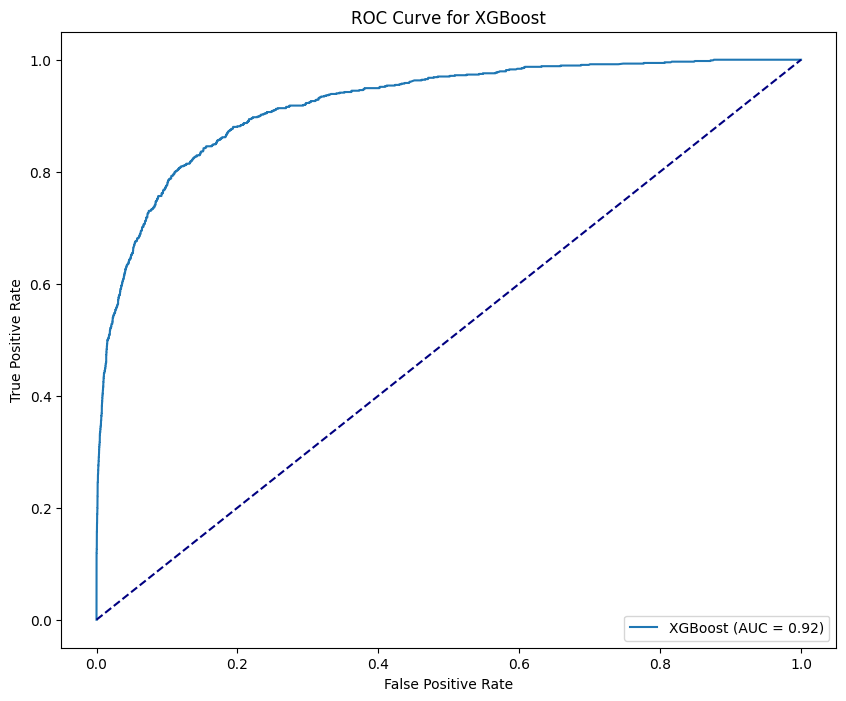

In [1]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, roc_curve, auc, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir los datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 1. Ajuste de max_depth y min_child_weight
xgb1 = XGBClassifier(objective='binary:logistic', learning_rate=0.1, n_estimators=10)

param_test1 = {'max_depth': range(3, 7, 1), 'min_child_weight': range(1, 3, 1)}

gsearch1 = GridSearchCV(estimator=xgb1, param_grid=param_test1, scoring='roc_auc', cv=5)
gsearch1.fit(X_train, y_train)

print("Mejores parámetros (max_depth y min_child_weight):", gsearch1.best_params_)
print("Mejor score:", gsearch1.best_score_)

# 2. Ajuste de gamma
xgb2 = XGBClassifier(objective='binary:logistic', learning_rate=0.1, n_estimators=10, max_depth=gsearch1.best_params_['max_depth'], min_child_weight=gsearch1.best_params_['min_child_weight'])

gamma_test = {'gamma': [i / 100.0 for i in range(0, 6)]}

gsearch2 = GridSearchCV(estimator=xgb2, param_grid=gamma_test, scoring='roc_auc', cv=5)
gsearch2.fit(X_train, y_train)

print("Mejores parámetros (gamma):", gsearch2.best_params_)
print("Mejor score:", gsearch2.best_score_)

# 3. Ajuste de subsample y colsample_bytree
xgb3 = XGBClassifier(objective='binary:logistic', learning_rate=0.1, n_estimators=23, max_depth=gsearch1.best_params_['max_depth'], min_child_weight=gsearch1.best_params_['min_child_weight'], gamma=gsearch2.best_params_['gamma'])

sample_test = {'subsample': [i / 10.0 for i in range(5, 9)], 'colsample_bytree': [i / 10.0 for i in range(5, 9)]}

gsearch3 = GridSearchCV(estimator=xgb3, param_grid=sample_test, scoring='roc_auc', cv=5)
gsearch3.fit(X_train, y_train)

print("Mejores parámetros (subsample y colsample_bytree):", gsearch3.best_params_)
print("Mejor score:", gsearch3.best_score_)

# 4. Ajuste de reg_alpha y reg_lambda (Regularización)
xgb4 = XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,
    n_estimators=23,
    max_depth=gsearch1.best_params_['max_depth'],
    min_child_weight=gsearch1.best_params_['min_child_weight'],
    gamma=gsearch2.best_params_['gamma'],
    subsample=gsearch3.best_params_['subsample'],
    colsample_bytree=gsearch3.best_params_['colsample_bytree']
)

reg_test = {'reg_alpha': [0, 0.01, 0.1], 'reg_lambda': [1, 1.1, 1.2, 1.3]}

gsearch4 = GridSearchCV(estimator=xgb4, param_grid=reg_test, scoring='roc_auc', cv=5)
gsearch4.fit(X_train, y_train)

print("Mejores parámetros (reg_alpha y reg_lambda):", gsearch4.best_params_)
print("Mejor score:", gsearch4.best_score_)

# 5. Modelo final con los mejores parámetros
xgb_final = XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,
    n_estimators=30,  # Puedes ajustar este valor según el rendimiento
    max_depth=gsearch1.best_params_['max_depth'],
    min_child_weight=gsearch1.best_params_['min_child_weight'],
    gamma=gsearch2.best_params_['gamma'],
    subsample=gsearch3.best_params_['subsample'],
    colsample_bytree=gsearch3.best_params_['colsample_bytree'],
    reg_alpha=gsearch4.best_params_['reg_alpha'],
    reg_lambda=gsearch4.best_params_['reg_lambda']
)

xgb_final.fit(X_train, y_train)

# Predicción en el conjunto de validación
y_val_proba = xgb_final.predict_proba(X_val)[:, 1]
y_val_pred = xgb_final.predict(X_val)

# Evaluar las métricas
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss: {log_loss_val:.4f}")

conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()